# Estimate $\epsilon_{r}$ and $\sigma$

## Preparation

### Imports

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from   _Constants import *
from   _Functions import *

### Parameters

In [ ]:
DATA_PATH       = "../Data"

ER_SCAN_CENTER  = 18e0      # log sweep with center 18 -> use lin sweep after you identify minimum
ER_SCAN_RANGE   = 0.2       # from 10^-.5 to 10^.5 times scan center
ER_SCAN_POINTS  = 501       # try these many values

S_SCAN_CENTER   = 3.5e-6    # 5.69e-8
S_SCAN_RANGE    = 0.2       # 2
S_SCAN_POINTS   = 501

eps_r_try       = ER_SCAN_CENTER * (1 + np.linspace(-ER_SCAN_RANGE, ER_SCAN_RANGE, ER_SCAN_POINTS)) #(10 ** np.linspace(-S_SCAN_RANGE, S_SCAN_RANGE, S_SCAN_POINTS))
sigma_try       =  S_SCAN_CENTER * (1 + np.linspace(-S_SCAN_RANGE, S_SCAN_RANGE, S_SCAN_POINTS))    #(10 ** np.linspace(-S_SCAN_RANGE, S_SCAN_RANGE, S_SCAN_POINTS))

### Load Files

In [125]:
Cp_by_Measurement = pd.read_csv(f"{DATA_PATH}/Cp_by_Measurement.csv")
Gp_by_Measurement = pd.read_csv(f"{DATA_PATH}/Gp_by_Measurement.csv")

Cp_by_Measurement.set_index(Cp_by_Measurement.iloc[:, 0].values, inplace=True)
Gp_by_Measurement.set_index(Gp_by_Measurement.iloc[:, 0].values, inplace=True)

Cp_by_Measurement = Cp_by_Measurement.iloc[:, 1:]
Gp_by_Measurement = Gp_by_Measurement.iloc[:, 1:]

## Get MSE

### Helper Function

In [126]:
def calc_mse (
    df = Cp_by_Measurement,
    expected_Qty_by_Diameter = get_expected_Cp_by_Diameter(18)
):
    
    mse_total   = 0
    mse_by_diam = {}
    for diam in df["cap_diam"].unique():
        measured        = df.loc[df["cap_diam"] == diam].iloc[:, 6:]
        measured_vals   = measured.values
        measured_count  = measured.size
        
        expected_qty    = expected_Qty_by_Diameter[diam * 1e-6]

        diff            = (measured_vals - expected_qty)
        sse_this_diam   = (diff * diff).sum()
        mse_this_diam   = sse_this_diam / measured_count

        mse_by_diam[diam]   = mse_this_diam
        mse_total           += sse_this_diam

    mse_total /= df.iloc[:, 6:].size

    return mse_total, mse_by_diam

In [127]:
Cp_mse_by_eps_r = [calc_mse(Cp_by_Measurement, get_expected_Cp_by_Diameter(er))[0] for er in eps_r_try]
Gp_mse_by_sigma = [calc_mse(Gp_by_Measurement, get_expected_Gp_by_Diameter(s))[0]  for s  in sigma_try]

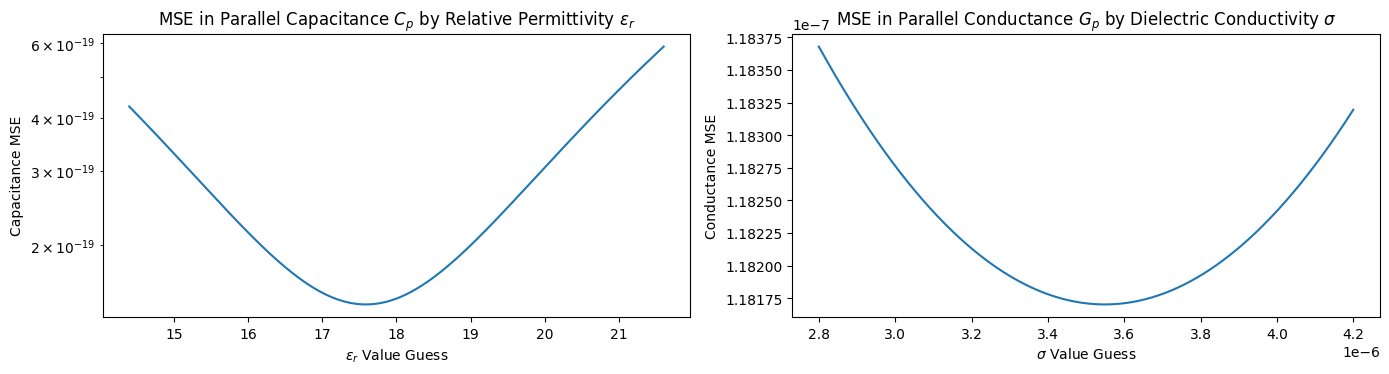

In [131]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].set_title("MSE in Parallel Capacitance $C_{p}$ by Relative Permittivity $\\epsilon_{r}$")
ax[0].set_xlabel("$\\epsilon_{r}$ Value Guess")
ax[0].set_ylabel("Capacitance MSE")
ax[0].set_yscale("log")
ax[0].plot(eps_r_try, Cp_mse_by_eps_r)

ax[1].set_title("MSE in Parallel Conductance $G_{p}$ by Dielectric Conductivity $\\sigma$")
ax[1].set_xlabel("$\\sigma$ Value Guess")
ax[1].set_ylabel("Conductance MSE")
ax[1].plot(sigma_try, Gp_mse_by_sigma)
plt.tight_layout()

In [129]:
Cp_mse_min_i    = np.argmin(Cp_mse_by_eps_r)
Gp_mse_min_i    = np.argmin(Gp_mse_by_sigma)

print(f"Minimum Cp MSE is {Cp_mse_by_eps_r[Cp_mse_min_i]:.3e} at eps_r = {eps_r_try[Cp_mse_min_i]:.6f}")
print(f"Minimum Gp MSE is {Gp_mse_by_sigma[Gp_mse_min_i]:.3e} at sigma =  {sigma_try[Gp_mse_min_i]*1e6:.6f} uS * m/m^2")

Minimum Cp MSE is 1.449e-19 at eps_r = 17.582400
Minimum Gp MSE is 1.182e-07 at sigma =  3.550400 uS * m/m^2
